## Feed-Forward Neural Network (FFNN)

This Jupyter notebook explains the code for training a feed-forward neural network with different hyperparameters included in the script _ffnn_search_v2.py_. 

It is divided in 2 stages:


**Stage 1**:
- Random search over hyperparameters:
    * Number of hidden layers: 1–3 
    * Widths: {256, 512, 1024, 2048}
    * Activation: {tanh, ReLU, GELU, LeakyReLU}
    * Dropout: {0.0, 0.1, 0.2}
    * BatchNorm: {True, False}
    * BatchSize: {128, 192, 256}
    * Learning Rate: {$10^{-3}, 2·10^{-3}, 3·10^{-3}$}
- Max 50 epochs, early stopping + global pruning from epoch >= 30
- 100 trials (different configurations of hyperparameters)
- Saves: arch_search_results_stage1.csv, arch_search_summary_stage1.json, best_model_stage1.pt

**Stage 2**:
- Loads top-K configs from Stage-1 CSV (by val_mse)
- Retrains each for up to 200 epochs with early stopping (no global pruning)
- K = 5
- Saves: arch_search_results_stage2.csv, arch_search_summary_stage2.json, best_model_stage2.pt

**Both stages**:
- Use log1p(Y_tx) as targets, standardized Xg_log1p as inputs
- Compute test MSE + Pearson for best-by-val model in that stage

In [ ]:
import os, json, math, random, csv, time, pathlib, ast
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

Now, we set a global configuration. Here, we include a seed, important to ensure the reproducibility of the code, irrespective of who runs it or when. It also allows for a fair comparison between architectures, as we ensure that the weights are initialized the same way. We want to run the model and all the tensors in an NVIDIA CUDA-enabled GPU if available, which is essential to accelerate the analyses.

In [ ]:
SEED      = 42
TEST_FRAC = 0.15
VAL_FRAC  = 0.15
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
AMP       = (DEVICE == "cuda")

This code is run in two stages. In stage 1, we train 100 neural networks with different combinations of hyperparameters for 50 epochs. The five top-best performing configurations, i.e., the ones with the lowest validation error (TOP_K_STAGE2) are selected for the second stage, where they are fine-tuned for 200 epochs.

We set a value for gradient clipping (maximum L2 norm) to keep training stability by avoiding exploding gradients. The model performance will be computed and logged every 5 epochs, which we found to be a compromise between keeping track of the performance often enough without slowing down too much the training. 

In [ ]:
STAGE        = 2          # set to 1 or 2
TOP_K_STAGE2 = 5          # number of best configs from Stage 1 to retrain in Stage 2

GRAD_CLIP    = 1.0
EVAL_EVERY   = 5          # evaluate every N epochs (both stages)

In the following cell, you can see how all hyperparameters are defined and the configuration of the two different stages of execution for this script.

In [ ]:
# HPO search ranges (Stage 1)
BATCHES    = [128, 192, 256]
LRS        = [1e-3, 2e-3, 3e-3]
DROPOUTS   = [0.0, 0.1, 0.2]
BATCHNORMS = [False, True]
ACTS       = ["tanh", "relu", "gelu", "leakyrelu"]

# Architecture space: up to 3 layers, widths in this set
DEPTH_CHOICES = [1, 2, 3]
WIDTH_CHOICES = [256, 512, 1024, 2048]

# Stage-specific config
if STAGE == 1:
    N_TRIALS        = 100
    MAX_EPOCHS      = 50
    PATIENCE        = 5
    MIN_PRUNE_EPOCH = 30   # don't prune before this epoch
    PRUNE_FACTOR    = 1.5  # prune if val is > 1.5x global best
elif STAGE == 2:
    # N_TRIALS will be set after loading top-K from Stage-1 CSV
    N_TRIALS        = TOP_K_STAGE2
    MAX_EPOCHS      = 200
    PATIENCE        = 10
    MIN_PRUNE_EPOCH = None
    PRUNE_FACTOR    = None
else:
    raise ValueError("STAGE must be 1 or 2")

The running of both stages yielded a top 5 best performing models in terms of MSE and Pearson correlation. In the following cells, those results are imported from a CSV to generate some plots to visualize these two parameters in the top 5 models. 

## Generate plots to visualize validation MSE and Pearson correlation

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Set the theme for seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "figure.dpi": 300
})

In [3]:
# Path to the architecture search results CSV file
results_path = "~/DeepIsoQ/ffnn_search/results/arch_search_results_stage2.csv"
# Load the results into a DataFrame
results_df = pd.read_csv(results_path)
print("Loaded architecture search results:")
print(results_df.head())


Loaded architecture search results:
                 name  hidden        act  dropout  batchnorm     lr momentum  \
0   L1_512_t53_stage2   [512]       tanh      0.0       True  0.003        -   
1  L1_1024_t25_stage2  [1024]  leakyrelu      0.0       True  0.003        -   
2  L1_1024_t41_stage2  [1024]  leakyrelu      0.1       True  0.001        -   
3   L1_1024_t5_stage2  [1024]  leakyrelu      0.1       True  0.002        -   
4  L1_1024_t56_stage2  [1024]       gelu      0.2       True  0.001        -   

  step_size gamma  batch_size  epochs_trained   val_mse  val_pearson  \
0         -     -         128             200  0.843434     0.744078   
1         -     -         256             200  0.843881     0.744401   
2         -     -         128             200  0.859592     0.741751   
3         -     -         192             200  0.857438     0.742168   
4         -     -         128             200  0.841696     0.746201   

   train_time_sec  
0           243.9  
1         

In [4]:
#Sort by validation MSE
df_mse = results_df.sort_values("val_mse", ascending = True)

#Sort by validation Pearson correlation
df_pearson = results_df.sort_values("val_pearson", ascending = False)


/tmp/ipykernel_1713801/2442136500.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1713801/2442136500.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


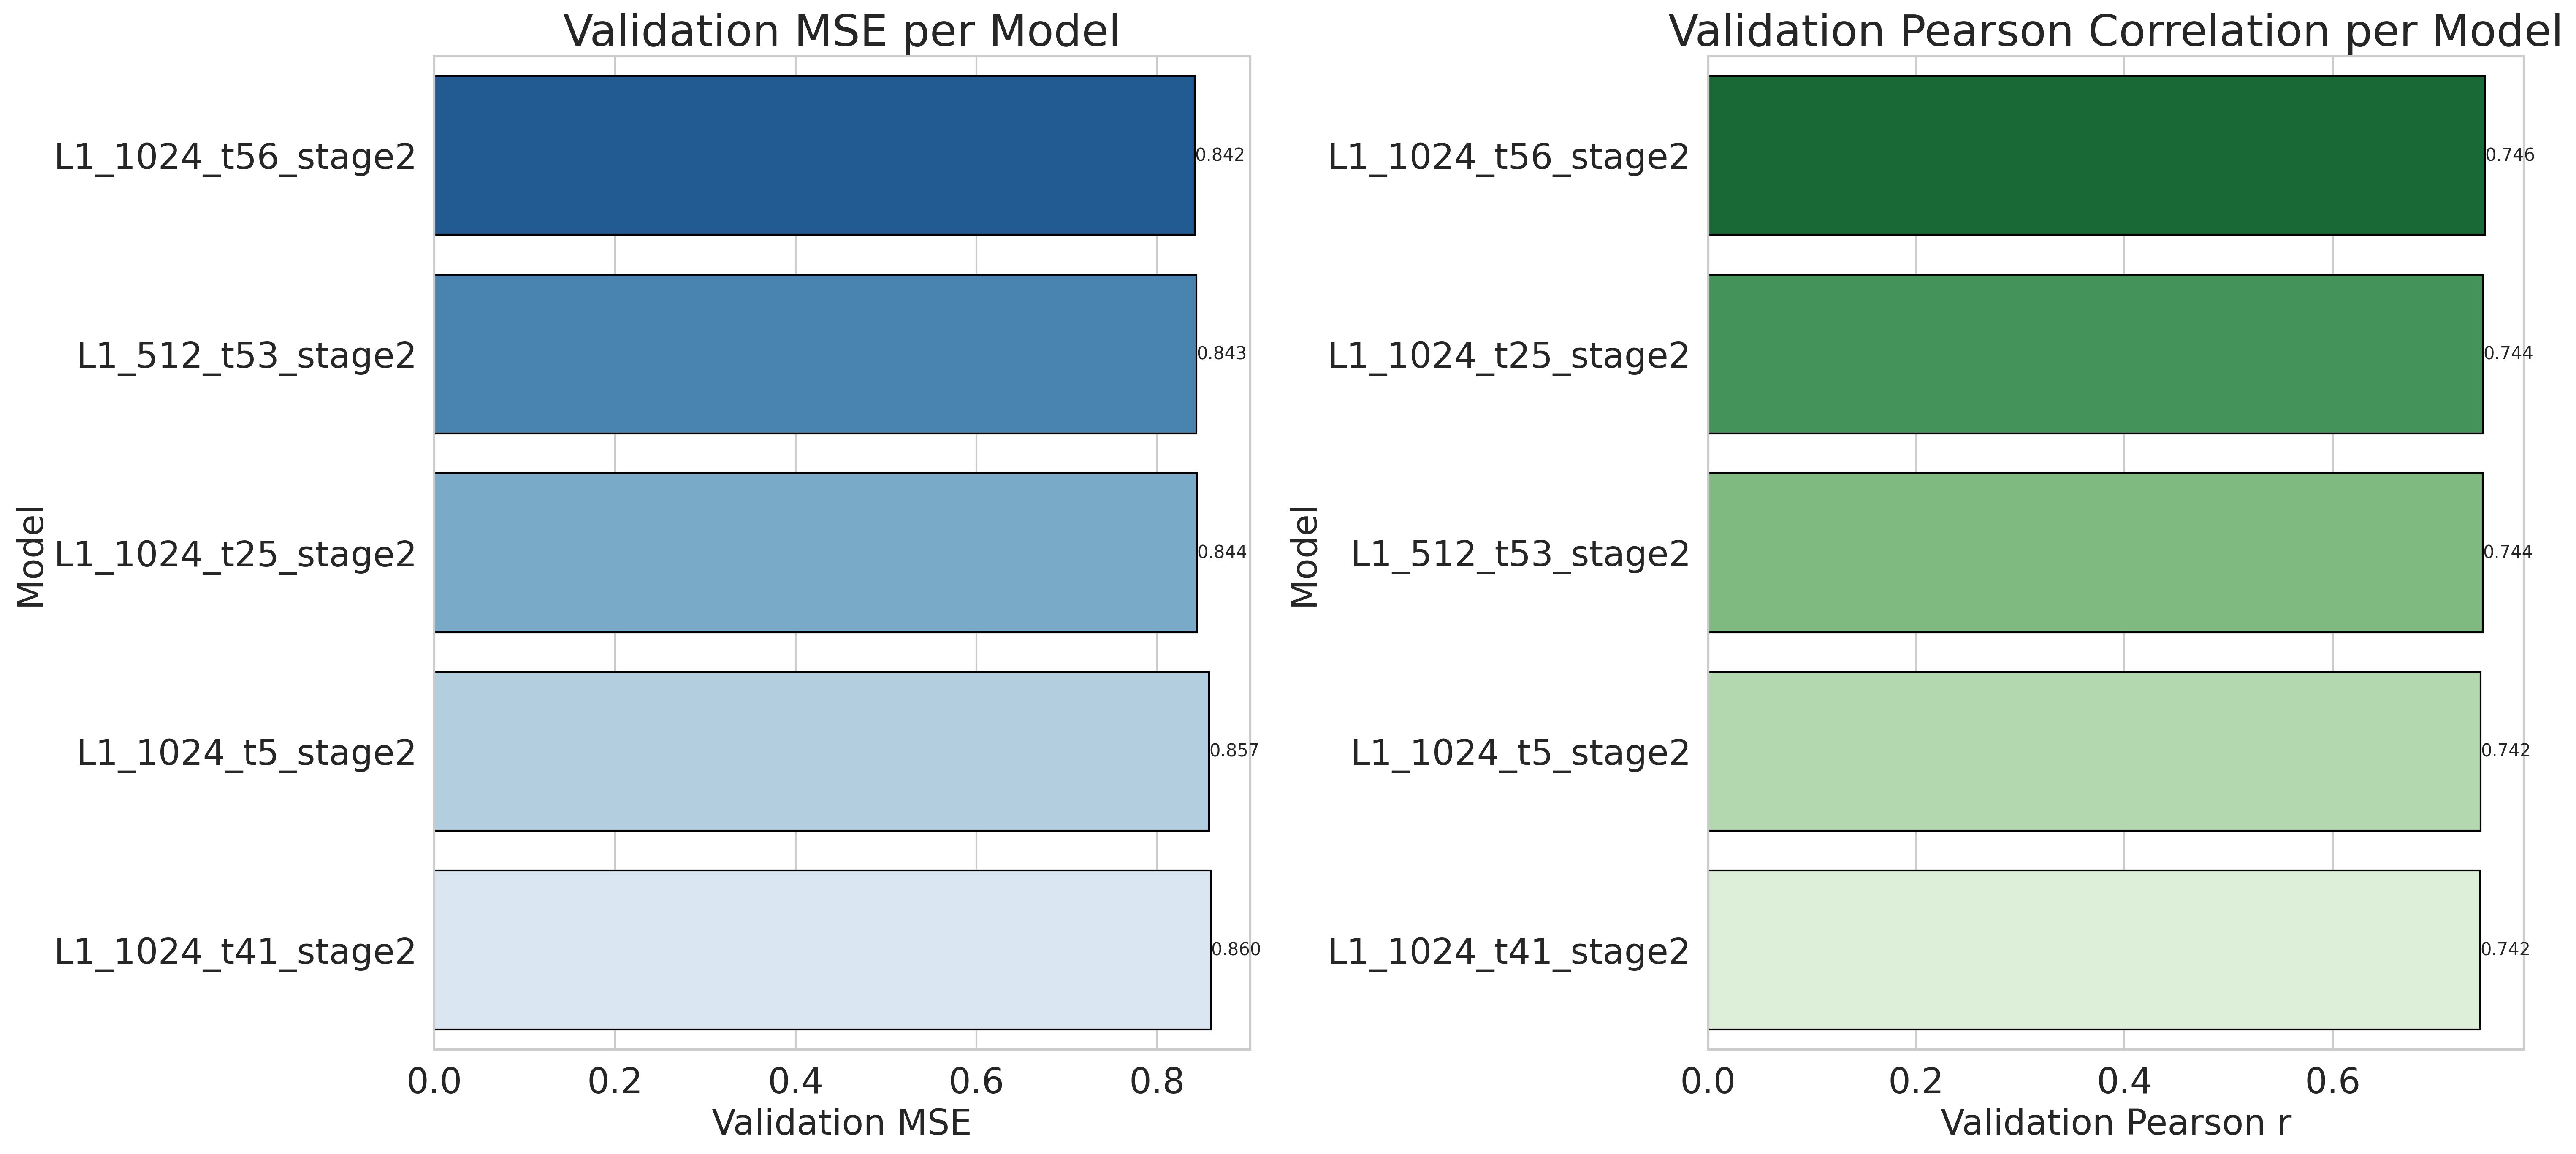

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

# Validation MSE
sns.barplot(
    ax=axes[0],
    data=df_mse,
    y="name",
    x="val_mse",
    palette="Blues_r",
    edgecolor="black"
)
axes[0].set_title("Validation MSE per Model")
axes[0].set_xlabel("Validation MSE")
axes[0].set_ylabel("Model")
# Annotate bars with MSE values
for i, v in enumerate(df_mse["val_mse"]):
    axes[0].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Validation Pearson Correlation
sns.barplot(
    ax=axes[1],
    data=df_pearson,
    y="name",
    x="val_pearson",
    palette="Greens_r",
    edgecolor="black"
)
axes[1].set_title("Validation Pearson Correlation per Model")
axes[1].set_xlabel("Validation Pearson r")
axes[1].set_ylabel("Model")
# Annotate bars with Pearson r values
for i, v in enumerate(df_pearson["val_pearson"]):
    axes[1].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

plt.show()

### Adding Residual Connections to the MLP Architecture

The script _ffnn_search_resnet.py_ builds on the previous one by extending the feed-forward architecture to support residual connections. The goal is to allow experimentation with a residual variant within the same training framework.

To new components where introduce: 
- **ResidualBlock**: A building block that applies: two linear transformations, optional batch normalization,a non-linear activation, optional dropout, and a residual shortcut.

- **ResidualFFNN**: A residual version of the multilayer perceptron.
Instead of stacking simple linear layers, it stacks multiple **ResidualBlocks**, one for each hidden dimension specified in the architecture.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# Path to the architecture search results CSV file
results_path = "~/DeepIsoQ/ffnn_search/results/residuals_arch_search_results_stage2.csv"

# Load the results into a DataFrame
results_df = pd.read_csv(results_path)
print("Loaded architecture search results:")
print(results_df.head())

Loaded architecture search results:
                         name             hidden        act  dropout  \
0  L3_256_2048_2048_t3_stage2  [256, 2048, 2048]  leakyrelu      0.0   
1            L1_512_t0_stage2              [512]       gelu      0.0   
2           L1_256_t10_stage2              [256]       gelu      0.0   

   batchnorm     lr momentum step_size gamma  batch_size  epochs_trained  \
0       True  0.001        -         -     -         192             100   
1       True  0.002        -         -     -         192             135   
2       True  0.002        -         -     -         128             125   

    val_mse  val_pearson  train_time_sec  residual  
0  0.926542     0.716932           514.4      True  
1  0.949994     0.710659           264.5      True  
2  0.981363     0.698767           190.4      True  


In [8]:
# Sort by validation MSE
df_mse = results_df.sort_values("val_mse", ascending=True)

# Sort by validation Pearson correlation
df_pearson = results_df.sort_values("val_pearson", ascending=False)

/tmp/ipykernel_1713801/2628662278.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1713801/2628662278.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


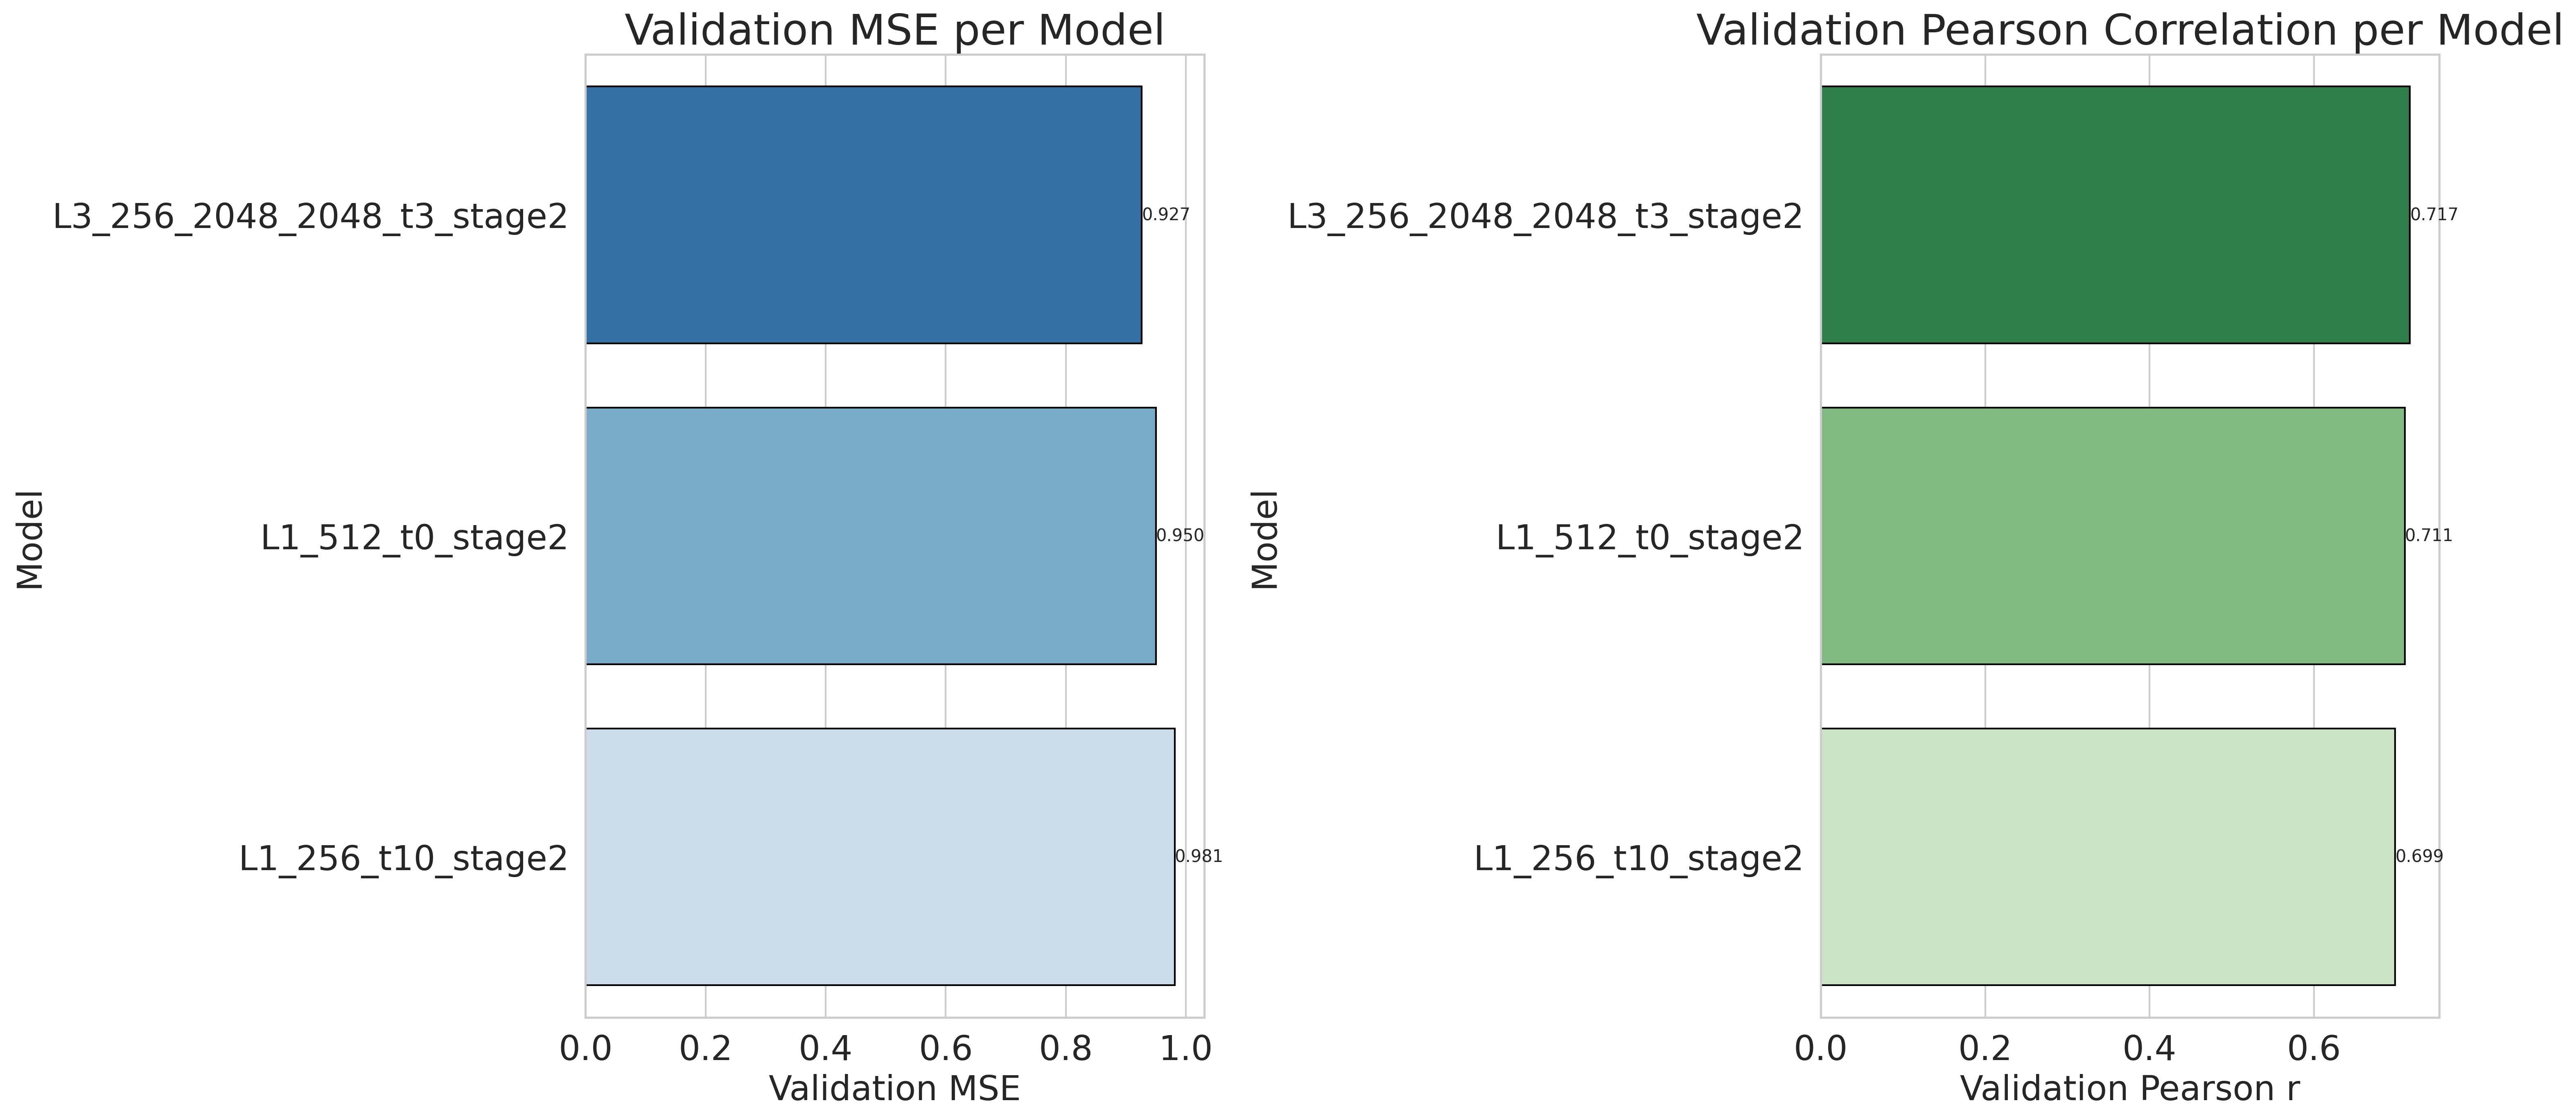

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

# Validation MSE
sns.barplot(
    ax=axes[0],
    data=df_mse,
    y="name",
    x="val_mse",
    palette="Blues_r",
    edgecolor="black"
)
axes[0].set_title("Validation MSE per Model")
axes[0].set_xlabel("Validation MSE")
axes[0].set_ylabel("Model")

# Annotate bars with MSE values
for i, v in enumerate(df_mse["val_mse"]):
    axes[0].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Validation Pearson Correlation
sns.barplot(
    ax=axes[1],
    data=df_pearson,
    y="name",
    x="val_pearson",
    palette="Greens_r",
    edgecolor="black"
)
axes[1].set_title("Validation Pearson Correlation per Model")
axes[1].set_xlabel("Validation Pearson r")
axes[1].set_ylabel("Model")

# Annotate bars with Pearson r values
for i, v in enumerate(df_pearson["val_pearson"]):
    axes[1].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

plt.show()
